In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
from src.pipeline.features.context_features import ContextFeatureEngineer

s22 = pd.read_parquet('data/processed/2021-22_Regular_Season_training_data.parquet')
s22 = ContextFeatureEngineer().enrich(s22)
s22['position_encoded'] = s22['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s23 = pd.read_parquet('data/processed/2022-23_Regular_Season_training_data.parquet')
s23 = ContextFeatureEngineer().enrich(s23)
s23['position_encoded'] = s23['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s24 = pd.read_parquet('data/processed/2023-24_Regular_Season_training_data.parquet')
s24 = ContextFeatureEngineer().enrich(s24)
s24['position_encoded'] = s24['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s25 = pd.read_parquet('data/processed/2024-25_Regular_Season_training_data.parquet')
s25 = ContextFeatureEngineer().enrich(s25)
s25['position_encoded'] = s25['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s26 = pd.read_parquet('data/processed/2025-26_Regular_Season_training_data.parquet')
s26 = ContextFeatureEngineer().enrich(s26)
s26['position_encoded'] = s26['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

df = pd.concat([s22, s23, s24, s25, s26], ignore_index=True)
df.sample(10)


Context features (pos, rest, trends, ranks, games played)

Merging player positions...
  loaded 624 positions from nba_2022_players.csv (season=2021-22)
  pos filled on 25,921 / 26,039 rows (1 season file(s))

Adding games_played to date...
  games_played + season_games_played

Adding rest / back-to-back...
  days_rest + is_back_to_back (3,830 B2B rows)

Adding fatigue window features...
  games_played_last_7/14_days + min_sum_last_7_days (from minutes)

Adding 5v20 trends...
  added 7 trend cols: ['base_min_trend_5v20', 'base_pts_per_min_trend_5v20', 'adv_ts_pct_trend_5v20', 'adv_usg_pct_trend_5v20', 'base_ast_per_min_trend_5v20', 'base_oreb_per_min_trend_5v20', 'base_dreb_per_min_trend_5v20']

Adding within-team ranks...
  added 7 rank cols: ['team_pts_per_min_rank_l10', 'team_ast_per_min_rank_l10', 'team_oreb_per_min_rank_l10', 'team_dreb_per_min_rank_l10', 'team_ts_pct_rank_l10', 'team_usg_pct_rank_l10', 'team_min_rank_l10']

Adding rolling team rank for pts_per_min (L10)...
  pts

,game_id,player_id,team_id,player_name,game_date,season_year,matchup,minutes,pts_per_min,fga_per_min,fg3a_per_min,fta_per_min,oreb_per_min,dreb_per_min,reb_per_min,ast_per_min,tov_per_min,stl_per_min,blk_per_min,blka_per_min,games_played,base_min_ewm_hl5,base_min_ewm_hl10,base_min_ewm_hl20,base_min_lag1,base_min_season_avg,base_fg_pct_ewm_hl5,base_fg_pct_ewm_hl10,base_fg_pct_ewm_hl20,base_fg_pct_lag1,base_fg_pct_season_avg,base_fg3_pct_ewm_hl5,base_fg3_pct_ewm_hl10,base_fg3_pct_ewm_hl20,base_fg3_pct_lag1,base_fg3_pct_season_avg,base_ft_pct_ewm_hl5,base_ft_pct_ewm_hl10,base_ft_pct_ewm_hl20,base_ft_pct_lag1,base_ft_pct_season_avg,base_plus_minus_ewm_hl5,base_plus_minus_ewm_hl10,base_plus_minus_ewm_hl20,base_plus_minus_lag1,base_plus_minus_season_avg,base_pts_per_min_ewm_hl5,base_pts_per_min_ewm_hl10,base_pts_per_min_ewm_hl20,base_pts_per_min_lag1,base_pts_per_min_season_avg,base_fga_per_min_ewm_hl5,base_fga_per_min_ewm_hl10,base_fga_per_min_ewm_hl20,base_fga_per_min_lag1,base_fga_per_min_season_avg,base_fg3a_per_min_ewm_hl5,base_fg3a_per_min_ewm_hl10,base_fg3a_per_min_ewm_hl20,base_fg3a_per_min_lag1,base_fg3a_per_min_season_avg,base_fta_per_min_ewm_hl5,base_fta_per_min_ewm_hl10,base_fta_per_min_ewm_hl20,base_fta_per_min_lag1,base_fta_per_min_season_avg,base_oreb_per_min_ewm_hl5,base_oreb_per_min_ewm_hl10,base_oreb_per_min_ewm_hl20,base_oreb_per_min_lag1,base_oreb_per_min_season_avg,base_dreb_per_min_ewm_hl5,base_dreb_per_min_ewm_hl10,base_dreb_per_min_ewm_hl20,base_dreb_per_min_lag1,base_dreb_per_min_season_avg,base_reb_per_min_ewm_hl5,base_reb_per_min_ewm_hl10,base_reb_per_min_ewm_hl20,base_reb_per_min_lag1,base_reb_per_min_season_avg,base_ast_per_min_ewm_hl5,base_ast_per_min_ewm_hl10,base_ast_per_min_ewm_hl20,base_ast_per_min_lag1,base_ast_per_min_season_avg,base_tov_per_min_ewm_hl5,base_tov_per_min_ewm_hl10,base_tov_per_min_ewm_hl20,base_tov_per_min_lag1,base_tov_per_min_season_avg,base_stl_per_min_ewm_hl5,base_stl_per_min_ewm_hl10,base_stl_per_min_ewm_hl20,base_stl_per_min_lag1,base_stl_per_min_season_avg,base_blk_per_min_ewm_hl5,base_blk_per_min_ewm_hl10,base_blk_per_min_ewm_hl20,base_blk_per_min_lag1,base_blk_per_min_season_avg,base_blka_per_min_ewm_hl5,base_blka_per_min_ewm_hl10,base_blka_per_min_ewm_hl20,base_blka_per_min_lag1,base_blka_per_min_season_avg,adv_off_rating_ewm_hl5,adv_off_rating_ewm_hl10,adv_off_rating_ewm_hl20,adv_off_rating_lag1,adv_off_rating_season_avg,adv_def_rating_ewm_hl5,adv_def_rating_ewm_hl10,adv_def_rating_ewm_hl20,adv_def_rating_lag1,adv_def_rating_season_avg,adv_net_rating_ewm_hl5,adv_net_rating_ewm_hl10,adv_net_rating_ewm_hl20,adv_net_rating_lag1,adv_net_rating_season_avg,adv_ast_pct_ewm_hl5,adv_ast_pct_ewm_hl10,adv_ast_pct_ewm_hl20,adv_ast_pct_lag1,adv_ast_pct_season_avg,adv_ast_ratio_ewm_hl5,adv_ast_ratio_ewm_hl10,adv_ast_ratio_ewm_hl20,adv_ast_ratio_lag1,adv_ast_ratio_season_avg,adv_oreb_pct_ewm_hl5,adv_oreb_pct_ewm_hl10,adv_oreb_pct_ewm_hl20,adv_oreb_pct_lag1,adv_oreb_pct_season_avg,adv_dreb_pct_ewm_hl5,adv_dreb_pct_ewm_hl10,adv_dreb_pct_ewm_hl20,adv_dreb_pct_lag1,adv_dreb_pct_season_avg,adv_reb_pct_ewm_hl5,adv_reb_pct_ewm_hl10,adv_reb_pct_ewm_hl20,adv_reb_pct_lag1,adv_reb_pct_season_avg,adv_efg_pct_ewm_hl5,adv_efg_pct_ewm_hl10,adv_efg_pct_ewm_hl20,adv_efg_pct_lag1,adv_efg_pct_season_avg,adv_ts_pct_ewm_hl5,adv_ts_pct_ewm_hl10,adv_ts_pct_ewm_hl20,adv_ts_pct_lag1,adv_ts_pct_season_avg,adv_usg_pct_ewm_hl5,adv_usg_pct_ewm_hl10,adv_usg_pct_ewm_hl20,adv_usg_pct_lag1,adv_usg_pct_season_avg,adv_pace_ewm_hl5,adv_pace_ewm_hl10,adv_pace_ewm_hl20,adv_pace_lag1,adv_pace_season_avg,adv_poss_ewm_hl5,adv_poss_ewm_hl10,adv_poss_ewm_hl20,adv_poss_lag1,adv_poss_season_avg,adv_pie_ewm_hl5,adv_pie_ewm_hl10,adv_pie_ewm_hl20,adv_pie_lag1,adv_pie_season_avg,starting,orbc_per_min,drbc_per_min,rbc_per_min,tchs_per_min,sast_per_min,ftast_per_min,pass_per_min,cfga_per_min,ufga_per_min,dfga_per_min,track_minutes_ewm_hl5,track_minutes_ewm_hl10,track_minutes_ewm_hl20,track_minutes_lag1,track_minutes_season_avg,track_spd

In [3]:
print(f"Total number of duplicates: {df.duplicated(subset=["game_id", "player_id"]).sum()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df[['minutes','pts_per_min', 'ast_per_min', 'reb_per_min']].describe()


Total number of duplicates: 0
Rows: 131291
Columns: 417


,minutes,pts_per_min,ast_per_min,reb_per_min
count,131291.000000,131279.000000,131279.000000,131279.000000
mean,22.617312,0.429593,0.099152,0.185916
std,10.761219,0.317961,0.117714,0.906028
min,0.000000,0.000000,0.000000,0.000000
25%,14.876667,0.229885,0.000000,0.083548
50%,23.633333,0.410526,0.078632,0.156556
75%,31.333333,0.599144,0.147420,0.251046
max,56.516667,30.000000,22.222222,300.000000


In [45]:
MIN_FEATURES = [
    'base_oreb_per_min_ewm_hl10',
    'base_dreb_per_min_ewm_hl10',
    'position_encoded',
    'track_orbc_per_min_ewm_hl10',
    'track_drbc_per_min_ewm_hl10'
]

In [46]:
print(f"Number of features: {df[MIN_FEATURES].shape[1]}")
print(f"Number of rows: {df[MIN_FEATURES].shape[0]}")

Number of features: 5
Number of rows: 111462


In [47]:
df = df[(df['minutes'] >= 10) | (df['starting'] == 1)]
print(f"After filtering games under 10 minutes: {df[MIN_FEATURES].shape[0]} rows")

After filtering games under 10 minutes: 111462 rows


In [48]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# 2025-26 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "reb_per_min"
ROLE_COL = "starting"

df_model = df[df["season_year"] != HOLDOUT_SEASON].copy()   # 2021-22 → 2024-25
df_holdout = df[df["season_year"] == HOLDOUT_SEASON].copy()  # 2025-26 blind test

KEEP_COLS = list(dict.fromkeys(
    MIN_FEATURES + ID_COLS + [TARGET_COL, ROLE_COL, "minutes"]
))

ppm_df = (
    df_model[KEEP_COLS]
    .sort_values("game_date")
    .reset_index(drop=True)
)

ppm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("game_date")
    .reset_index(drop=True)
)

X = ppm_df[MIN_FEATURES].copy()
y = ppm_df[TARGET_COL]

print(f"Train pool (2021-22 → 2024-25) : {len(ppm_df):,} rows")
print(f"Holdout   (2025-26)            : {len(ppm_holdout):,} rows")
print(f"Date range (train)   : {ppm_df['game_date'].min().date()} → {ppm_df['game_date'].max().date()}")
print(f"Date range (holdout) : {ppm_holdout['game_date'].min().date()} → {ppm_holdout['game_date'].max().date()}")


Train pool (2021-22 → 2024-25) : 88,737 rows
Holdout   (2025-26)            : 22,725 rows
Date range (train)   : 2021-10-19 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


In [49]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]

# est params: {'n_estimators': 1655, 'max_depth': 4, 'learning_rate': 0.03703121107469649, 'subsample': 0.548428652232707, 'colsample_bytree': 0.8325873147129733, 
# 'reg_alpha': 0.0059881368676087034, 'reg_lambda': 0.050446181208082655, 'min_child_weight': 4}

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1655,
    max_depth             = 4,
    learning_rate         = 0.03703121107469649,
    subsample             = 0.548428652232707,
    colsample_bytree      = 0.8325873147129733,
    reg_alpha             = 0.0059881368676087034,
    reg_lambda            = 0.050446181208082655,
    min_child_weight      = 4,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)

def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


In [50]:
# ── Helpers ───────────────────────────────────────────────────────────────────

MIN_TIERS = {
    "<0.15 reb/min":    lambda a: a < 0.15,
    "0.15-0.25 reb/min": lambda a: (a >= 0.15) & (a < 0.25),
    "0.25-0.40 reb/min": lambda a: (a >= 0.25) & (a < 0.40),
    "0.40+ reb/min":    lambda a: a >= 0.40,
}


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    CHANGED: now accepts `starting` (bool/int array) and reports
    stratified MAE + coverage across roles and minutes tiers.
    Coverage is tracked per-fold so we can report mean±std at the end.
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.3f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.3f} | Coverage: {r_cov:.1%}")

    # ── Minutes-tier stratification ────────────────────────────────────────────
    for tier, fn in MIN_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:10s} | n={mask.sum():5d} | MAE: {t_mae:.3f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = ppm_df["starting"].iloc[val_idx].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]          for r in tscv_results]
r2s  = [r["r2"]           for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# CHANGED: splits are now on unique GAME_DATEs, not row indices.
# This ensures no single game date is split across train/val,
# which was the root cause of intra-game leakage in the original code.
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

assert ppm_df["game_date"].is_monotonic_increasing, "ppm_df must be sorted by GAME_DATE"

unique_dates  = ppm_df["game_date"].unique()          # sorted unique game dates
n_dates       = len(unique_dates)

TRAIN_WINDOW  = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE     = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS       = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # CHANGED: mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = ppm_df["game_date"].isin(train_dates)
    val_mask   = ppm_df["game_date"].isin(val_dates)

    X_tr,  X_val  = X[train_mask],              X[val_mask]
    y_tr,  y_val  = y[train_mask],              y[val_mask]
    starting_val  = ppm_df["starting"][val_mask].values

    label = (f"WF fold {fold+1}  "
             f"({train_dates[-1].date()} → {val_dates[-1].date()})")

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash slices so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last = models
    preds_last  = preds
    X_val_last  = X_val
    y_val_last  = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]           for r in wf_results]
r2s  = [r["r2"]            for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# CHANGED: per-fold coverage table across all folds — catches folds where
# the interval collapses or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# CHANGED: stratified MAE summary across all folds
print(f"\nPer-fold MAE by minutes tier:")
tier_keys = list(MIN_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>10}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>10.3f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.3f}  {bar}")

last_fold = wf_results[-1]

── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=14789 | MAE: 0.072 | R²: 0.403 | 80% Coverage: 80.1%
  Starters   | n= 8138 | MAE: 0.065 | Coverage: 83.7%
  Bench      | n= 6651 | MAE: 0.079 | Coverage: 75.7%
  <0.15 reb/min | n= 6862 | MAE: 0.060 | Coverage: 77.1%
  0.15-0.25 reb/min | n= 4353 | MAE: 0.054 | Coverage: 93.3%
  0.25-0.40 reb/min | n= 2690 | MAE: 0.090 | Coverage: 77.8%
  0.40+ reb/min | n=  884 | MAE: 0.189 | Coverage: 45.1%

TSCV fold 2
  Overall  | n=14789 | MAE: 0.071 | R²: 0.413 | 80% Coverage: 79.6%
  Starters   | n= 8255 | MAE: 0.064 | Coverage: 83.5%
  Bench      | n= 6534 | MAE: 0.078 | Coverage: 74.7%
  <0.15 reb/min | n= 6896 | MAE: 0.057 | Coverage: 78.3%
  0.15-0.25 reb/min | n= 4336 | MAE: 0.056 | Coverage: 92.1%
  0.25-0.40 reb/min | n= 2665 | MAE: 0.088 | Coverage: 74.9%
  0.40+ reb/min | n=  892 | MAE: 0.190 | Coverage: 43.3%

TSCV fold 3
  Overall  | n=14789 | MAE: 0.072 | R²: 0.385 | 80% Coverage: 79.3%

In [51]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=4)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=40, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Residual Visuals

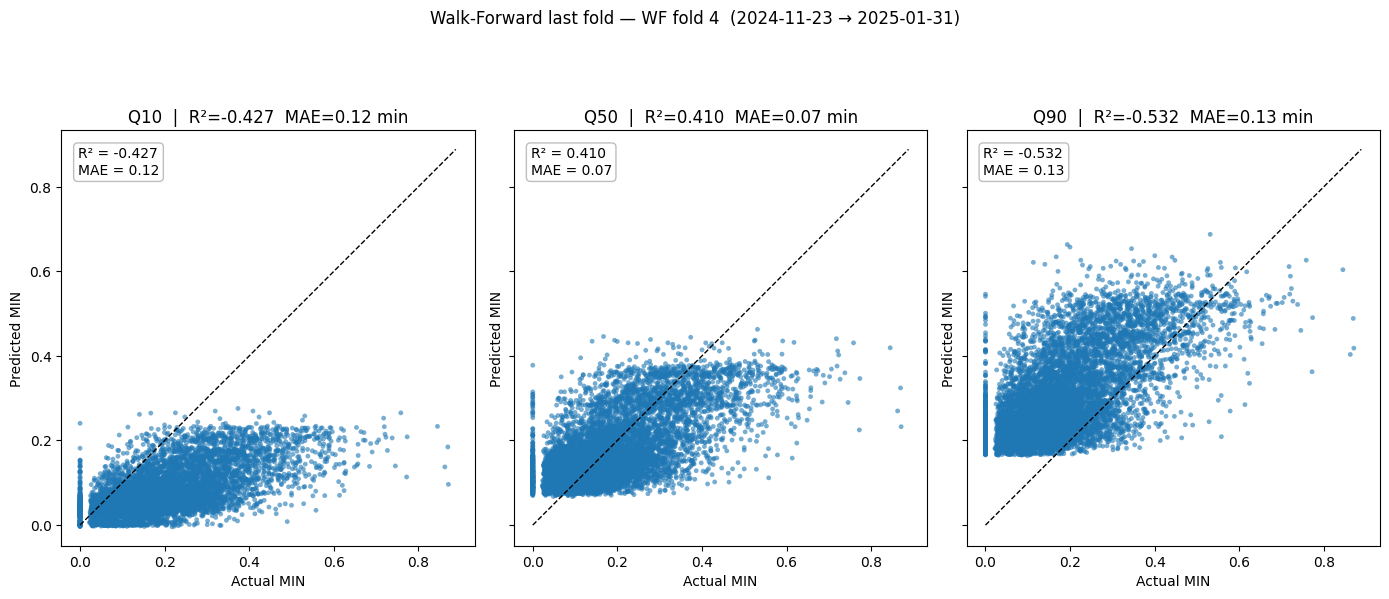

Per-quantile fit on last validation fold:
  Q10: R²=-0.427  MAE=0.117 min
  Q50: R²=+0.410  MAE=0.073 min
  Q90: R²=-0.532  MAE=0.131 min

Coverage per quantile (should match quantile value):
  Q10: 10.2%  (target 10%, delta +0.2%)  ✓
  Q50: 50.1%  (target 50%, delta +0.1%)  ✓
  Q90: 89.6%  (target 90%, delta -0.4%)  ✓

80% interval width (Q10→Q90):
  mean   : 0.23 min
  median : 0.21 min
  std    : 0.05 min


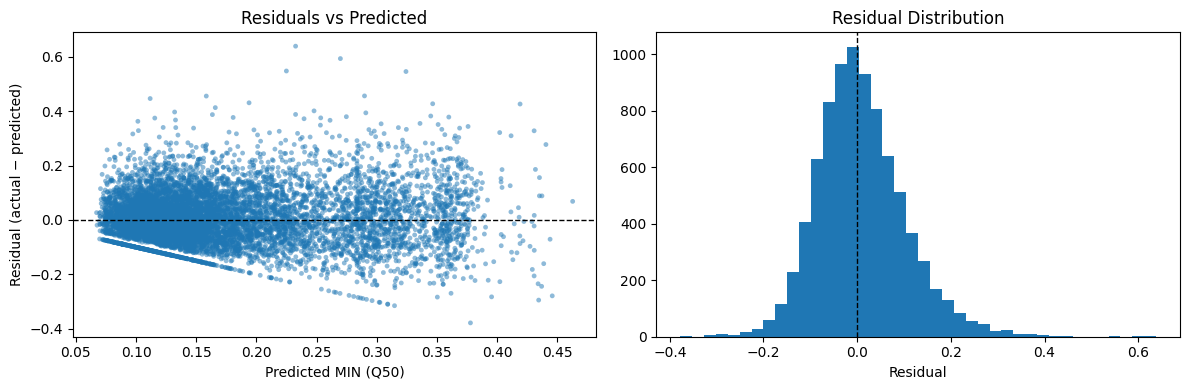


Residual summary:
  mean bias : +0.009 min  (close to 0 = unbiased)
  std       : 0.095 min

Residuals by role:
  Starters   | n= 4670 | bias=+0.009 | std=0.086
  Bench      | n= 3749 | bias=+0.008 | std=0.105

Residuals by minutes tier:
  <0.15 reb/min | n= 3847 | bias=-0.051 | std=0.057
  0.15-0.25 reb/min | n= 2440 | bias=+0.019 | std=0.067
  0.25-0.40 reb/min | n= 1588 | bias=+0.076 | std=0.078
  0.40+ reb/min | n=  544 | bias=+0.187 | std=0.095


In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.2f} min")
print(f"  median : {np.median(interval_width):.2f} min")
print(f"  std    : {interval_width.std():.2f} min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

# ── residuals stratified by role and minutes tier ─────────────────────────────
# uses starting_last set in the walk-forward loop
# ── re-derive starting using X_val_last.index (guaranteed same length as residuals) ──
starting_last = ppm_df.loc[X_val_last.index, "starting"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")

print("\nResiduals by minutes tier:")
for tier, fn in MIN_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")


── q_0.10 ──


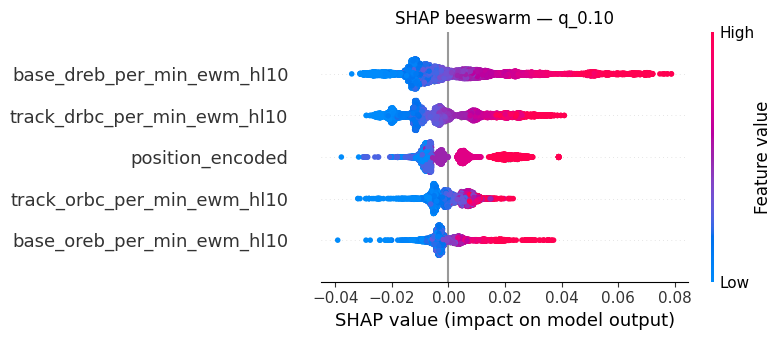


── q_0.50 ──


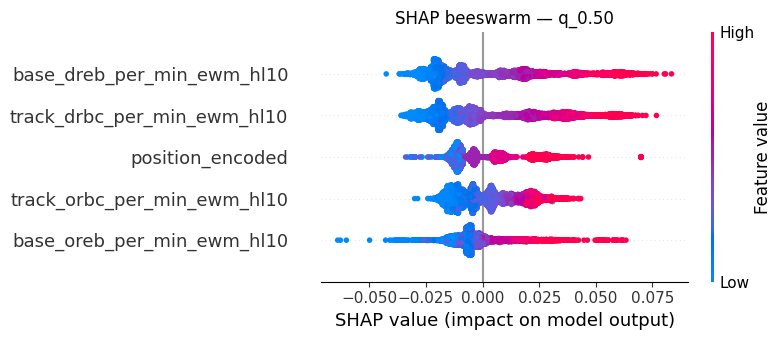


── q_0.90 ──


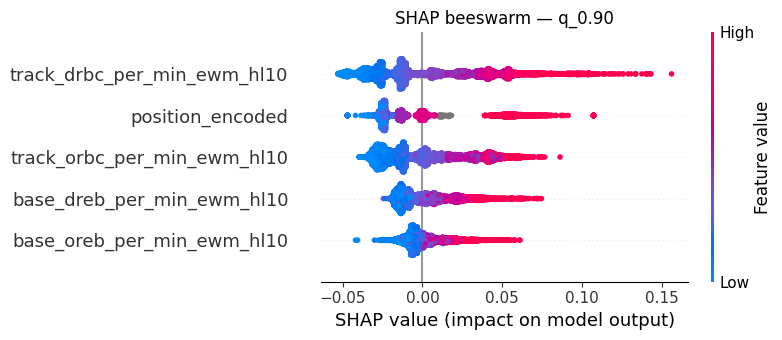

In [53]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

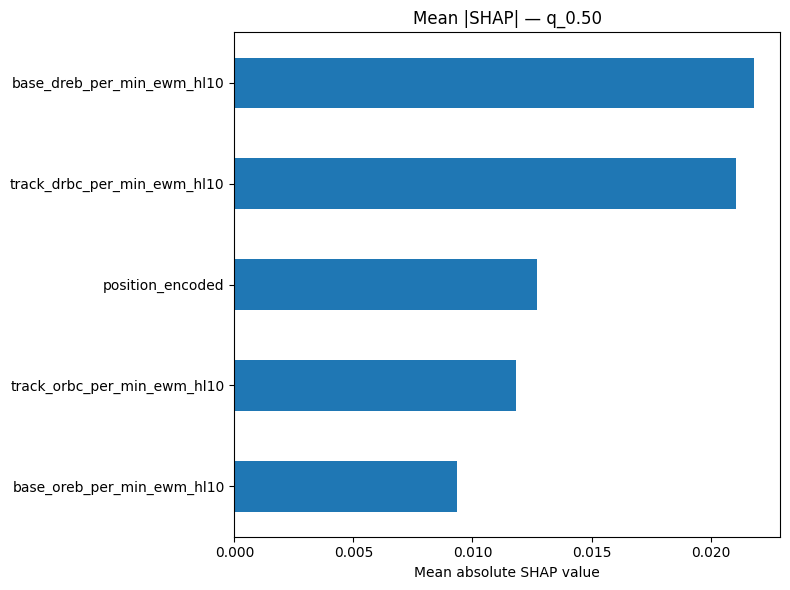

In [54]:
model = models_last["q_0.50"]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [42]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,   # ← no flip
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"]        = pi_df["std"].round(5)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                        feature  importance      std  p_value  significant
1    base_dreb_per_min_ewm_hl10     0.00218  0.00010      0.0         True
2   track_drbc_per_min_ewm_hl10     0.00200  0.00011      0.0         True
3   track_orbc_per_min_ewm_hl10     0.00127  0.00008      0.0         True
4              position_encoded     0.00111  0.00008      0.0         True
5    base_oreb_per_min_ewm_hl10     0.00110  0.00008      0.0         True
6  base_dreb_per_min_trend_5v20     0.00005  0.00001      0.0         True


In [43]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))

baseline_rmse = rmse_median_ablation(MIN_FEATURES)
print(f"Baseline RMSE (all features): {baseline_rmse:.4f}")

rows = []
for feat in MIN_FEATURES:
    cols         = [c for c in MIN_FEATURES if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 4), "delta_rmse": round(delta, 4)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())

Baseline RMSE (all features): 0.0954
                        feature  ablated_rmse  delta_rmse
1    base_dreb_per_min_ewm_hl10        0.0960      0.0006
2              position_encoded        0.0959      0.0005
3   track_orbc_per_min_ewm_hl10        0.0958      0.0004
4   track_drbc_per_min_ewm_hl10        0.0957      0.0003
5    base_oreb_per_min_ewm_hl10        0.0954      0.0000
6  base_dreb_per_min_trend_5v20        0.0955      0.0000


In [44]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model    = models_last["q_0.50"]
X_tr_last = X[last_fold["train_mask"]]   # only needed if you want train SHAP — not used below

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":        X_val_last.columns,
    "mean_abs_shap":  _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,              # ← was X_tr.columns
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())

                        feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1    base_dreb_per_min_ewm_hl10       0.022028          1          1          0.00218              0.00010  7.132485e-40          0.0006   1.000000   1.000000   1.000000   True
2   track_drbc_per_min_ewm_hl10       0.020144          2          2          0.00200              0.00011  9.512833e-38          0.0003   0.914484   0.917431   0.915958   True
3              position_encoded       0.012912          3          4          0.00111              0.00008  1.197808e-34          0.0005   0.586156   0.509174   0.547665   True
4   track_orbc_per_min_ewm_hl10       0.011140          4          3          0.00127              0.00008  4.929910e-36          0.0004   0.505733   0.582569   0.544151   True
5    base_oreb_per_min_ewm_hl10       0.009502          5          5          0.00110              0.00008  8.27020

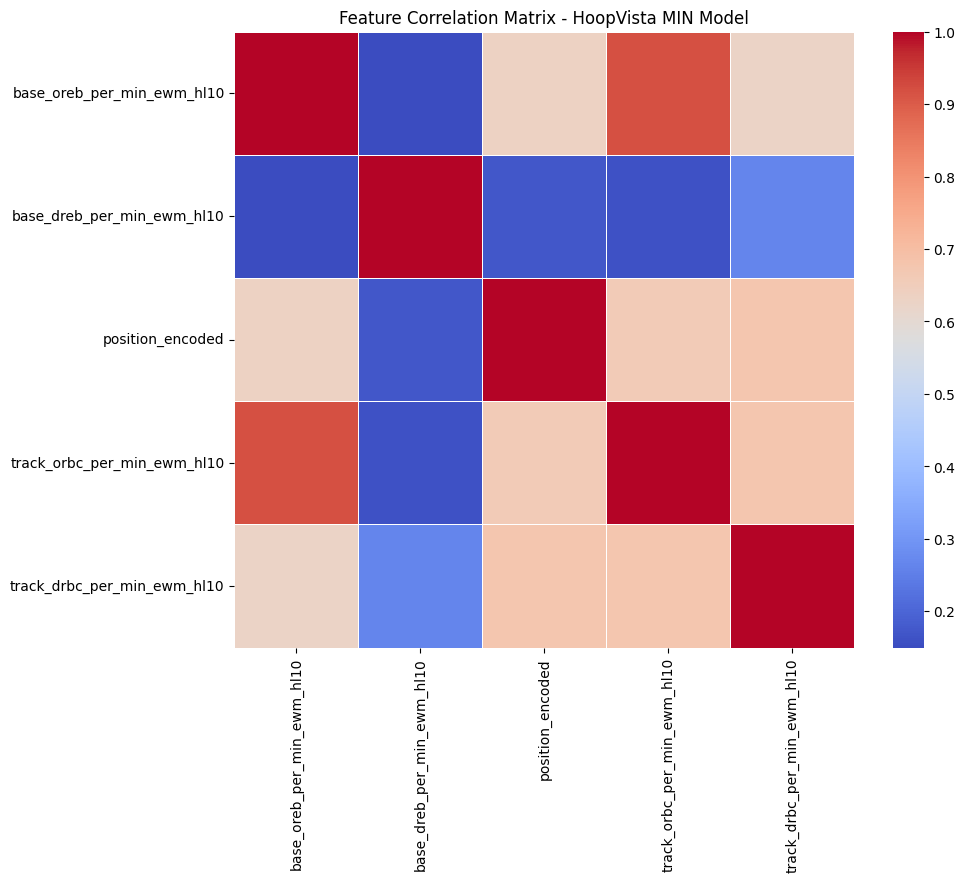

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [279]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [280]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S26
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S26 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S26 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S22–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).")

X_train_full = ppm_df[MIN_FEATURES]
y_train_full = ppm_df["reb_per_min"]
X_ho         = ppm_holdout[MIN_FEATURES]
y_ho         = ppm_holdout["reb_per_min"]
starting_ho  = ppm_holdout["starting"].values

# Early stopping on last 10% of training only — S26 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S26 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE — gap indicates how optimistic
# the WF estimate was
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S22–S25)  : {wf_mae_mean:.3f} min")
print(f"  Holdout MAE      (S26)            : {ho_mae:.3f} min")
print(f"  Gap                               : {gap:+.3f} min  {'⚠ investigate' if abs(gap) > 0.5 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred    = preds_ho[q_key]
    actual  = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta   = actual_coverage - target
    flag    = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.2f} min  |  median: {np.median(interval_width):.2f} min  |  std: {interval_width.std():.2f} min")

── S26 Blind Holdout Evaluation ─────────────────────────────────────
  S22–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).

S26 Blind Holdout
  Overall  | n=22725 | MAE: 0.074 | R²: 0.366 | 80% Coverage: 79.6%
  Starters   | n=12300 | MAE: 0.067 | Coverage: 83.5%
  Bench      | n=10425 | MAE: 0.081 | Coverage: 75.0%
  <0.15 reb/min | n=10443 | MAE: 0.061 | Coverage: 77.9%
  0.15-0.25 reb/min | n= 6745 | MAE: 0.055 | Coverage: 94.0%
  0.25-0.40 reb/min | n= 4193 | MAE: 0.095 | Coverage: 73.0%
  0.40+ reb/min | n= 1344 | MAE: 0.198 | Coverage: 42.0%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S22–S25)  : 0.072 min
  Holdout MAE      (S26)            : 0.074 min
  Gap                               : +0.001 min  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 10.4%  target: 10%  delta: +0.4%  ✓
  q_0.50 | actual coverage: 50.8%  target: 50%  delta: +0.8%  ✓
  q_0.

In [281]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/
# Assumes notebook lives somewhere inside the repo (e.g. notebooks/ or root).

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   MIN_FEATURES,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       ppm_df["game_date"].max(),
    "val_end":         ppm_holdout["game_date"].max(),
}

save_path = save_dir / f"rpm_nba_model_{ppm_holdout['game_date'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.3f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_minutes(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as MIN_FEATURES.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to /Users/alexgonzalez/Documents/NBA-Prop-Predictor/src/models/saved_models/rpm_nba_model_2026-04-12.joblib
Loaded model MAE (S26 holdout): 0.074
Trained on data up to        : 2025-04-13
Holdout through              : 2026-04-12
